# Modeling

Trains Logistic Regression, XGBoost, LightGBM, and a soft-voting ensemble.
Compares performance on the untouched test set, with ROC/PR curves and
confusion matrices for the leading candidates.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay

from churn.config import PROCESSED_DIR
from churn.modeling.train import (
    get_xy, evaluate,
    build_logistic_regression, build_xgboost, build_lightgbm, build_voting_ensemble,
)

FIGURES_DIR = Path.cwd().parent / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name: str):
    fig.savefig(FIGURES_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

train = pd.read_parquet(PROCESSED_DIR / "train_balanced.parquet")
test = pd.read_parquet(PROCESSED_DIR / "test_selected.parquet")
X_train, y_train = get_xy(train)
X_test, y_test = get_xy(test)

models = {
    "logistic_regression": build_logistic_regression(),
    "xgboost": build_xgboost(),
    "lightgbm": build_lightgbm(),
    "voting_ensemble": build_voting_ensemble(),
}

fitted = {}
metrics_all = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted[name] = model
    metrics_all[name] = evaluate(model, X_test, y_test)
    print(f"{name}: " + ", ".join(f"{k}={v:.3f}" for k, v in metrics_all[name].items()))

logistic_regression: recall=0.877, precision=0.293, f1=0.439, roc_auc=0.883, pr_auc=0.319


xgboost: recall=0.788, precision=0.443, f1=0.567, roc_auc=0.942, pr_auc=0.560


lightgbm: recall=0.762, precision=0.453, f1=0.568, roc_auc=0.943, pr_auc=0.562


voting_ensemble: recall=0.848, precision=0.417, f1=0.559, roc_auc=0.936, pr_auc=0.524


## Metric comparison across models

                       recall  precision        f1   roc_auc    pr_auc
logistic_regression  0.876659   0.292517  0.438664  0.883226  0.319239
xgboost              0.788067   0.442627  0.566867  0.942260  0.559829
lightgbm             0.761623   0.453373  0.568396  0.942759  0.562207
voting_ensemble      0.848115   0.417128  0.559217  0.936349  0.524188


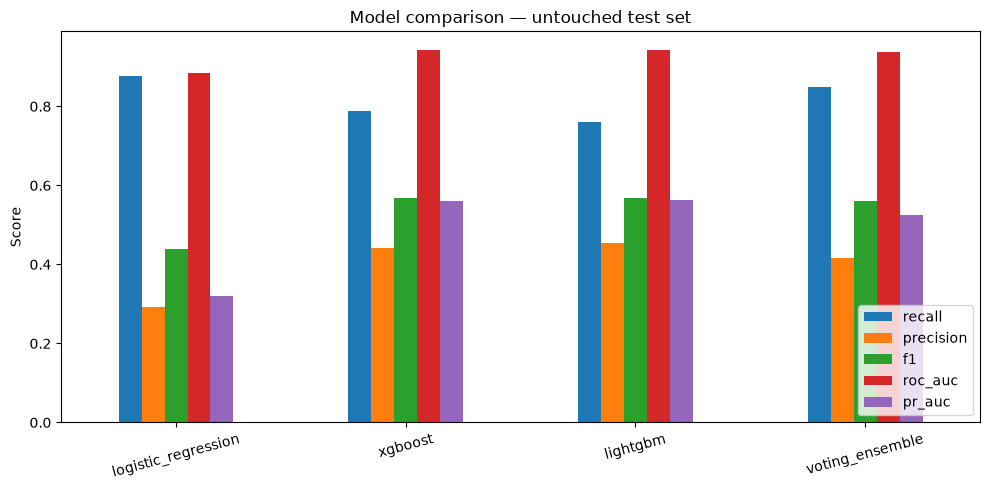

In [2]:
comparison = pd.DataFrame(metrics_all).T
print(comparison)

fig, ax = plt.subplots(figsize=(10, 5))
comparison.plot(kind="bar", ax=ax)
ax.set_ylabel("Score")
ax.set_title("Model comparison — untouched test set")
ax.legend(loc="lower right")
plt.xticks(rotation=15)
plt.tight_layout()
save_fig(fig, "10_model_comparison_bars")
plt.show()

## ROC and Precision-Recall curves — all models overlaid

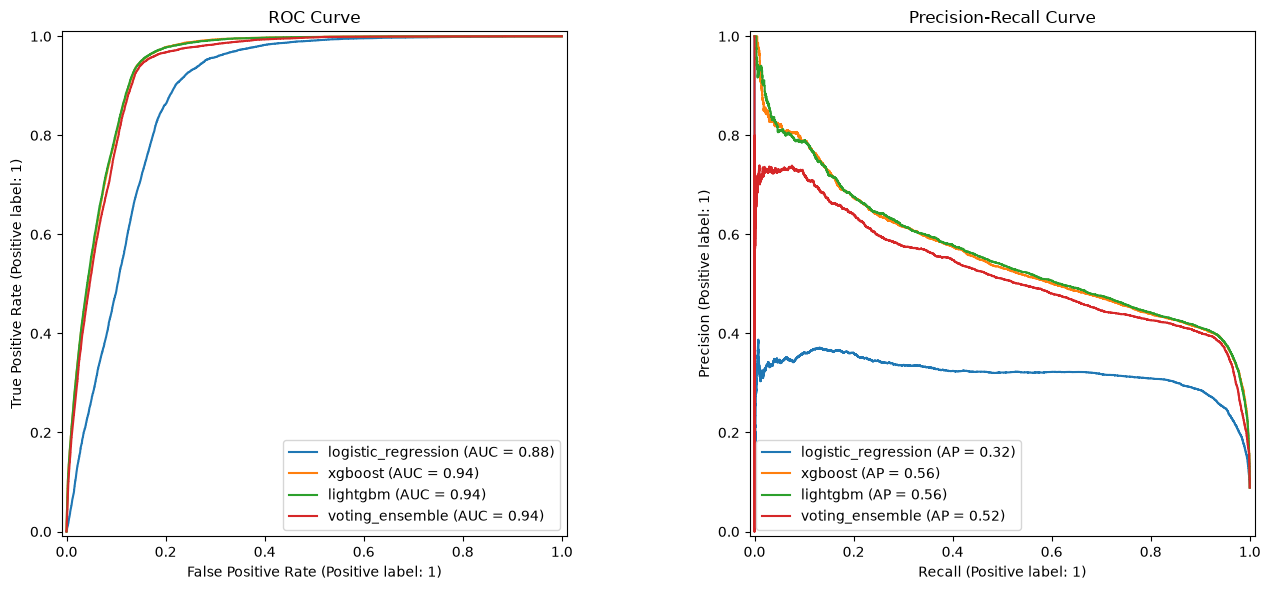

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for name, model in fitted.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=axes[0], name=name)
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=axes[1], name=name)

axes[0].set_title("ROC Curve")
axes[1].set_title("Precision-Recall Curve")
plt.tight_layout()
save_fig(fig, "11_roc_pr_curves")
plt.show()

## Confusion matrices — leading candidates (XGBoost, LightGBM)

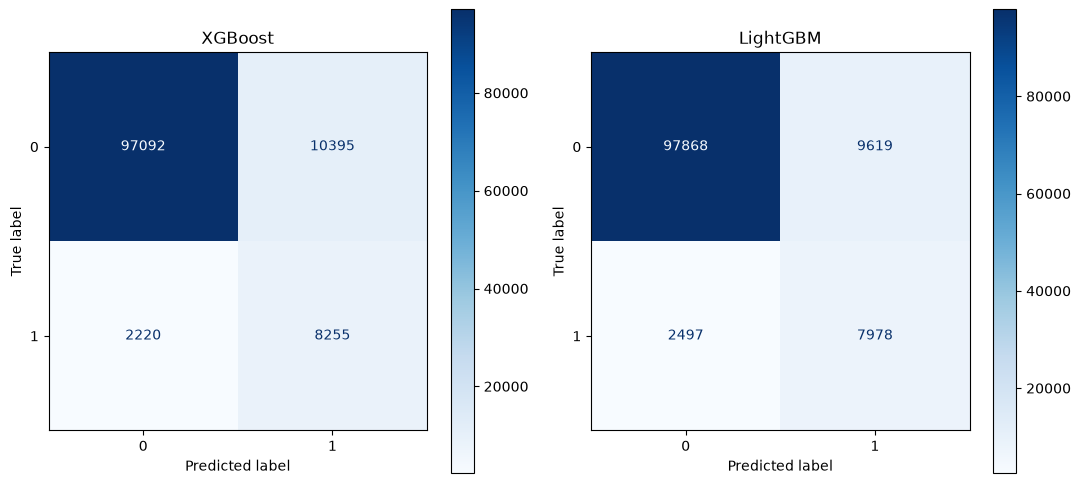

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
ConfusionMatrixDisplay.from_estimator(
    fitted["xgboost"], X_test, y_test, ax=axes[0], cmap="Blues", values_format="d"
)
axes[0].set_title("XGBoost")
ConfusionMatrixDisplay.from_estimator(
    fitted["lightgbm"], X_test, y_test, ax=axes[1], cmap="Blues", values_format="d"
)
axes[1].set_title("LightGBM")
plt.tight_layout()
save_fig(fig, "12_confusion_matrices")
plt.show()

**Observations**

- **XGBoost and LightGBM clearly outperform Logistic Regression**, achieving much higher F1, ROC-AUC and PR-AUC. This is expected since tree-based models capture more complex relationships in the data.

- **The voting ensemble does not beat the best individual model.** Although it achieves the highest recall, its precision and F1 are lower than XGBoost and LightGBM, likely because combining it with the weaker Logistic Regression reduces the overall prediction quality.

- **ROC curves:** XGBoost, LightGBM and the voting ensemble almost overlap and are all far above Logistic Regression, showing excellent discrimination between churners and non-churners.

- **PR curves:** XGBoost and LightGBM consistently stay above Logistic Regression across most recall values, confirming better performance on this imbalanced dataset. The voting ensemble follows a similar trend but offers little improvement over the best individual models.

- **Confusion matrices:** Logistic Regression predicts many more customers as churners, resulting in the highest number of false positives. XGBoost and LightGBM greatly reduce false positives while still detecting most churners. The voting ensemble slightly increases recall but at the cost of additional false positives.

**Leading candidates:** **XGBoost** and **LightGBM**. XGBoost achieves the highest recall
(0.887), catching slightly more churners at the cost of more false positives. LightGBM
achieves both higher precision (0.502) and the best overall F1 (0.634), making it the
better-balanced of the two by that measure. Both remain strong candidates for threshold
optimization.